# Registered Analysis Pipeline

In [1]:
# ── Packages ──────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import statsmodels.api as sm
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings
import seaborn as sns
warnings.filterwarnings('ignore')

## Build Dataframe for Full Sample

### Data for H1 Models

In [2]:
# ── Build combined_df for behavior-related data ──────────────────────────────────────────────────────────
pre_counts = pd.read_csv("../data/pre_history_b_results.csv")
post_count = pd.read_csv("../data/post_history_c_results.csv")

keep_cols = [
    "participant_id",
    "assignment",
    "ai_adjusted_videos",
    "share_ai_adjusted_videos",
    "ai_adjusted_watch_time",
    "share_ai_adjusted_watch_time",
]

pre_counts = pre_counts[keep_cols].rename(columns={
    "ai_adjusted_videos": "pre_ai_videos",
    "share_ai_adjusted_videos": "pre_share_ai_videos",
    "ai_adjusted_watch_time": "pre_ai_watch_time",
    "share_ai_adjusted_watch_time": "pre_share_ai_watch_time",
})

post_count = post_count[keep_cols].rename(columns={
    "ai_adjusted_videos": "post_ai_videos",
    "share_ai_adjusted_videos": "post_share_ai_videos",
    "ai_adjusted_watch_time": "post_ai_watch_time",
    "share_ai_adjusted_watch_time": "post_share_ai_watch_time",
})

combined_df = pre_counts.merge(
    post_count,
    on=["participant_id", "assignment"],
    how="inner"
)

combined_df["assignment"] = combined_df["assignment"].map({
    "Control": 0,
    "Treatment": 1
})
combined_df = combined_df.rename(columns={"assignment": "treatment"})

print(len(combined_df)) # should be 301

301


### Data for H2 + H3 Models

In [3]:
# ── Read from local Excel file ─────────────────────────────────────────────
FILE = '../data/qualtrics.xlsx'

s1 = pd.read_excel(FILE, sheet_name='survey_1')
s2 = pd.read_excel(FILE, sheet_name='survey_2')
s3 = pd.read_excel(FILE, sheet_name='survey_3')
s4 = pd.read_excel(FILE, sheet_name='participants')[['PROLIFIC_PID', 'GROUP']]

In [4]:
# ── Correct GAAIS column names ─────────────────────────────────────────────
correct_names = [
    'GAAIS_1',  'GAAIS_2',  'GAAIS_3',  'ATT_1',   'GAAIS_4',
    'GAAIS_5',  'GAAIS_6',  'GAAIS_7',  'GAAIS_8',  'GAAIS_9',
    'ATT_2',    'GAAIS_10', 'GAAIS_11', 'GAAIS_12', 'GAAIS_13',
    'GAAIS_14', 'GAAIS_15', 'GAAIS_16', 'GAAIS_17', 'GAAIS_18',
    'ATT_3',    'GAAIS_19', 'GAAIS_20'
]

# Rename by position
def rename_cols_by_position(df, start, end, new_names):
    cols = df.columns.tolist()
    cols[start:end] = new_names
    df.columns = cols
    return df

s1 = rename_cols_by_position(s1, 15, 38, correct_names)
s2 = rename_cols_by_position(s2, 10, 33, correct_names)
s3 = rename_cols_by_position(s3, 2, 25, correct_names)

In [5]:
# ── Build df_long for plotting attitude-realted data ──────────────────────────────────────────────────────────
valid_pids = s3['PROLIFIC_PID'].unique()

df_long = pd.concat([
    s1[s1['PROLIFIC_PID'].isin(valid_pids)].assign(time=1),
    s2[s2['PROLIFIC_PID'].isin(valid_pids)].assign(time=2),
    s3[s3['PROLIFIC_PID'].isin(valid_pids)].assign(time=3)
], ignore_index=True)

df_long = df_long.merge(s4, on='PROLIFIC_PID', how='left')
print(len(df_long)) # should be 301x3=903 (since we have attitude data for each participant at 3 points)

903


In [6]:
# ── Likert recode since some questions are negatively worded ──────────────────────────────────────────────────────────
likert_recode = {
    'Strongly Disagree':          1,
    'Disagree':                   2,
    'Somewhat disagree':          3,
    'Neither agree nor disagree': 4,
    'Somewhat agree':             5,
    'Agree':                      6,
    'Strongly agree':             7
}

gaais_cols = [f'GAAIS_{i}' for i in range(1, 21)]
neg_items  = ['GAAIS_3','GAAIS_6','GAAIS_8','GAAIS_9',
               'GAAIS_10','GAAIS_15','GAAIS_19','GAAIS_20']
pos_items  = ['GAAIS_1','GAAIS_2','GAAIS_4','GAAIS_5','GAAIS_7',
               'GAAIS_11','GAAIS_12','GAAIS_13','GAAIS_14',
               'GAAIS_16','GAAIS_17','GAAIS_18']

# Recode text -> numbers
df_long[gaais_cols] = df_long[gaais_cols].replace(likert_recode)
df_long[gaais_cols] = df_long[gaais_cols].apply(pd.to_numeric, errors='coerce')

# Reverse-code negative items (8 - x)
df_long[neg_items] = 8 - df_long[neg_items]

# GAAIS total (row sum)
df_long['GAAIS_total'] = df_long[gaais_cols].sum(axis=1, skipna=True)

In [7]:
# ── Prepare wide format for regression for H2+H3 ────────────────────────────────────────────────────
keep_cols = ['PROLIFIC_PID', 'GROUP', 'time'] + correct_names + ['GAAIS_total']
df_sub = df_long[df_long['time'].isin([1,2,3])][keep_cols].copy()

df_wide = df_sub.pivot_table(
    index   = ['PROLIFIC_PID', 'GROUP'],
    columns = 'time',
    values  = correct_names + ['GAAIS_total'],
    aggfunc = 'first'
)

# Flatten MultiIndex columns: (varname, time) -> varname_t1
df_wide.columns = [f"{v}_t{t}" for v, t in df_wide.columns]
df_wide = df_wide.reset_index()

df_wide = df_wide.rename(columns={
    'GAAIS_total_t1': 'GAAIS_baseline',
    'GAAIS_total_t2': 'GAAIS_post',
    'GAAIS_total_t3': 'GAAIS_followup'
})

df_wide['D1'] = df_wide['GAAIS_post']     - df_wide['GAAIS_baseline']
df_wide['D2'] = df_wide['GAAIS_followup'] - df_wide['GAAIS_baseline']
df_wide["GROUP"] = df_wide["GROUP"].map({
    "control": 0,
    "treatment": 1
})

print(len(df_wide)) # should be 301

301


## Results on Full Sample

### H1A: AI Count

In [8]:
# ── H1A on full dataset ──────────────────────────────────────────────────────────
h1_a = smf.poisson(
    formula="post_ai_videos ~ treatment + pre_ai_videos",
    data=combined_df
).fit(cov_type="HC1")
print(h1_a.summary())

Optimization terminated successfully.
         Current function value: 4.146032
         Iterations 8
                          Poisson Regression Results                          
Dep. Variable:         post_ai_videos   No. Observations:                  301
Model:                        Poisson   Df Residuals:                      298
Method:                           MLE   Df Model:                            2
Date:                Sun, 13 Sep 2026   Pseudo R-squ.:                  0.3273
Time:                        11:14:48   Log-Likelihood:                -1248.0
converged:                       True   LL-Null:                       -1855.2
Covariance Type:                  HC1   LLR p-value:                1.935e-264
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         1.1719      0.115     10.150      0.000       0.946       1.398
treatment         0.

In [9]:
irr = np.exp(h1_a.params.treatment)
lower_ci = np.exp(h1_a.conf_int()[0].treatment)
upper_ci = np.exp(h1_a.conf_int()[1].treatment)
print(f"IRR: {irr}")
print(f"95% CI: [{lower_ci}, {upper_ci}]")

IRR: 1.1436591856653158
95% CI: [0.8518126950590421, 1.5354975812681382]


### H1B: Share of AI Videos

In [10]:
# ── H1B on full dataset ──────────────────────────────────────────────────────────
h1_b = smf.ols(
    formula="post_share_ai_videos ~ treatment + pre_share_ai_videos",
    data=combined_df
).fit(cov_type="HC1")
print(h1_b.summary())

                             OLS Regression Results                             
Dep. Variable:     post_share_ai_videos   R-squared:                       0.133
Model:                              OLS   Adj. R-squared:                  0.127
Method:                   Least Squares   F-statistic:                     12.65
Date:                  Sun, 13 Sep 2026   Prob (F-statistic):           5.35e-06
Time:                          11:14:55   Log-Likelihood:                 601.09
No. Observations:                   301   AIC:                            -1196.
Df Residuals:                       298   BIC:                            -1185.
Df Model:                             2                                         
Covariance Type:                    HC1                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept     

### H1C: AI Total Watch Time

In [11]:
# ── H1C on full dataset ──────────────────────────────────────────────────────────
h1_c = smf.ols(
    formula="post_ai_watch_time ~ treatment + pre_ai_watch_time",
    data=combined_df
).fit(cov_type="HC1")
print(h1_c.summary())

                            OLS Regression Results                            
Dep. Variable:     post_ai_watch_time   R-squared:                       0.016
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     5.042
Date:                Sun, 13 Sep 2026   Prob (F-statistic):            0.00702
Time:                        11:14:59   Log-Likelihood:                -3157.0
No. Observations:                 301   AIC:                             6320.
Df Residuals:                     298   BIC:                             6331.
Df Model:                           2                                         
Covariance Type:                  HC1                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept           654.1218    183.17

### H1D: Share of AI Watch Time

In [12]:
# ── H1D on full dataset ──────────────────────────────────────────────────────────
h1_d = smf.ols(
    formula="post_share_ai_watch_time ~ treatment + pre_share_ai_watch_time",
    data=combined_df
).fit(cov_type="HC1")
print(h1_d.summary())

                               OLS Regression Results                               
Dep. Variable:     post_share_ai_watch_time   R-squared:                       0.025
Model:                                  OLS   Adj. R-squared:                  0.019
Method:                       Least Squares   F-statistic:                     4.582
Date:                      Sun, 13 Sep 2026   Prob (F-statistic):             0.0110
Time:                              11:15:04   Log-Likelihood:                 399.69
No. Observations:                       301   AIC:                            -793.4
Df Residuals:                           298   BIC:                            -782.3
Df Model:                                 2                                         
Covariance Type:                        HC1                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------

### H2 Descriptive Plots

In [13]:
# ── Basic scores by time x GROUP on full dataset ──────────────────────────────────────────
def ci95(x):
    x = x.dropna()
    se = x.std() / np.sqrt(len(x))
    return x.mean() - 1.96*se, x.mean() + 1.96*se

basic_scores = (df_long
    .groupby(['time', 'GROUP'])['GAAIS_total']
    .agg(
        mean  = 'mean',
        sd    = 'std',
        n     = 'count'
    )
    .reset_index())

basic_scores['se']    = basic_scores['sd'] / np.sqrt(basic_scores['n'])
basic_scores['ci_lo'] = basic_scores['mean'] - 1.96 * basic_scores['se']
basic_scores['ci_hi'] = basic_scores['mean'] + 1.96 * basic_scores['se']

print(basic_scores)

   time      GROUP       mean         sd    n        se      ci_lo      ci_hi
0     1    control  80.007407  26.704434  135  2.298352  75.502638  84.512177
1     1  treatment  86.156627  22.169038  166  1.720651  82.784151  89.529103
2     2    control  73.422222  26.359871  135  2.268696  68.975577  77.868867
3     2  treatment  80.566265  22.215306  166  1.724242  77.186750  83.945780
4     3    control  72.562963  23.079877  135  1.986400  68.669620  76.456306
5     3  treatment  78.397590  20.318339  166  1.577009  75.306653  81.488528


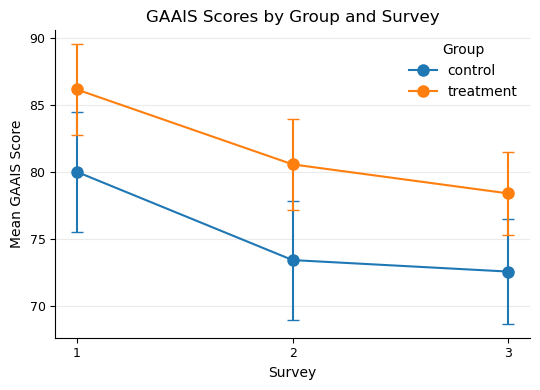

In [14]:
# ── Plot: GAAIS by Group and Time for full dataset ─────────────────────────────────────────

fig, ax = plt.subplots(figsize=(5.5, 4))

time_labels = {
    1: "1",
    2: "2",
    3: "3",
}

basic_scores["time_label"] = basic_scores["time"].map(time_labels)

for group, gdf in basic_scores.groupby("GROUP"):

    gdf = gdf.sort_values("time")

    line, = ax.plot(
        gdf["time_label"],
        gdf["mean"],
        marker="o",
        linewidth=1.5,
        markersize=8,
        label=group,
    )

    color = line.get_color()

    ax.errorbar(
        gdf["time_label"],
        gdf["mean"],
        yerr=[
            gdf["mean"] - gdf["ci_lo"],
            gdf["ci_hi"] - gdf["mean"],
        ],
        fmt="none",
        capsize=4,
        elinewidth=1.5,
        color=color,
    )

# Labels and title
ax.set_xlabel(
    "Survey",
    fontsize=10,
)

ax.set_ylabel(
    "Mean GAAIS Score",
    fontsize=10,
)

ax.set_title(
    "GAAIS Scores by Group and Survey",
    fontsize=12,
    pad=6,
)

# Tick styling
ax.tick_params(
    axis="both",
    labelsize=9,
)

# Clean axes
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="y",
    alpha=0.25,
)

# Legend
ax.legend(
    title="Group",
    frameon=False,
    fontsize=10,
    title_fontsize=10,
)

plt.tight_layout()

plt.savefig(
    "../figures/h2_gaais_by_group_time_full.pdf",
    format="pdf",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### H2A: Simple Difference Model

In [15]:
# ── H2a: Simple difference model on full dataset ──────────────────────────────────────────
h2a = smf.ols('D2 ~ GROUP', data=df_wide).fit(cov_type="HC1")
print(h2a.summary())

                            OLS Regression Results                            
Dep. Variable:                     D2   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.003
Method:                 Least Squares   F-statistic:                   0.07674
Date:                Sun, 13 Sep 2026   Prob (F-statistic):              0.782
Time:                        11:15:12   Log-Likelihood:                -1105.1
No. Observations:                 301   AIC:                             2214.
Df Residuals:                     299   BIC:                             2222.
Df Model:                           1                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -7.4444      0.933     -7.975      0.0

### H2B: Baseline Adjusted

In [16]:
# ── H2b: Baseline-adjusted ANCOVA on full dataset ─────────────────────────────────────────
h2b = smf.ols('GAAIS_followup ~ GROUP + GAAIS_baseline', data=df_wide).fit(cov_type="HC1")
print(h2b.summary())

                            OLS Regression Results                            
Dep. Variable:         GAAIS_followup   R-squared:                       0.850
Model:                            OLS   Adj. R-squared:                  0.849
Method:                 Least Squares   F-statistic:                     954.2
Date:                Sun, 13 Sep 2026   Prob (F-statistic):          2.80e-130
Time:                        11:15:16   Log-Likelihood:                -1068.6
No. Observations:                 301   AIC:                             2143.
Df Residuals:                     298   BIC:                             2154.
Df Model:                           2                                         
Covariance Type:                  HC1                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          7.1347      1.648      4.

### H3A: Using Spearman-Brown Reliability 

In [17]:
h3a = smf.ols('D2 ~ D1 * GROUP + D1 + GROUP', data=df_wide).fit(cov_type="HC1")
print(h3a.summary())

                            OLS Regression Results                            
Dep. Variable:                     D2   R-squared:                       0.407
Model:                            OLS   Adj. R-squared:                  0.401
Method:                 Least Squares   F-statistic:                     51.19
Date:                Sun, 13 Sep 2026   Prob (F-statistic):           1.07e-26
Time:                        11:15:19   Log-Likelihood:                -1026.4
No. Observations:                 301   AIC:                             2061.
Df Residuals:                     297   BIC:                             2076.
Df Model:                           3                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -3.1146      0.708     -4.398      0.0

In [18]:
# ── H3A robustness on full dataset: Split-half attenuation correction ──────────────────────
np.random.seed(42)
gaais_only = [c for c in correct_names if c.startswith('GAAIS_')]
items_A = list(np.random.choice(gaais_only, 10, replace=False))
items_B = [c for c in gaais_only if c not in items_A]

df_wide['GAAIS_base_A'] = df_wide[[f"{c}_t1" for c in items_A]].mean(axis=1)
df_wide['GAAIS_base_B'] = df_wide[[f"{c}_t1" for c in items_B]].mean(axis=1)
df_wide['GAAIS_post_A'] = df_wide[[f"{c}_t2" for c in items_A]].mean(axis=1)
df_wide['GAAIS_post_B'] = df_wide[[f"{c}_t2" for c in items_B]].mean(axis=1)
df_wide['GAAIS_follow_A'] = df_wide[[f"{c}_t3" for c in items_A]].mean(axis=1)
df_wide['GAAIS_follow_B'] = df_wide[[f"{c}_t3" for c in items_B]].mean(axis=1)


df_wide['D1_A'] = df_wide['GAAIS_post_A'] - df_wide['GAAIS_base_A']
df_wide['D1_B'] = df_wide['GAAIS_post_B'] - df_wide['GAAIS_base_B']

# Spearman-Brown reliability
complete = df_wide[['D1_A', 'D1_B']].dropna()
r_halves, _ = stats.pearsonr(complete['D1_A'], complete['D1_B'])
reliability  = (2 * r_halves) / (1 + r_halves)

print(f"\nD1 split-half reliability (Spearman-Brown): r = {reliability:.3f}")

# Attenuation-corrected b3
b3_raw       = h3a.params.get('D1:GROUP[T.Treatment]', h3a.params.filter(like='D1:GROUP').iloc[0])
b3_corrected = b3_raw / reliability

print(f"b3 raw:       {b3_raw:.3f}")
print(f"b3 corrected: {b3_corrected:.3f}")


D1 split-half reliability (Spearman-Brown): r = 0.808
b3 raw:       -0.168
b3 corrected: -0.208


### H3B: Using Random Splits for D1

In [19]:
# ── H3B on full dataset ─────────────────────────────────────────────────────────
h3b = smf.ols('D2 ~ D1_A * GROUP + D1_B + GROUP', data=df_wide).fit(cov_type="HC1")
print(h3b.summary())

                            OLS Regression Results                            
Dep. Variable:                     D2   R-squared:                       0.418
Model:                            OLS   Adj. R-squared:                  0.410
Method:                 Least Squares   F-statistic:                     38.97
Date:                Sun, 13 Sep 2026   Prob (F-statistic):           3.33e-26
Time:                        11:15:22   Log-Likelihood:                -1023.7
No. Observations:                 301   AIC:                             2057.
Df Residuals:                     296   BIC:                             2076.
Df Model:                           4                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -3.1634      0.742     -4.261      0.0

## Results on Weighted Sample

In [20]:
weights_df = pd.read_csv("../data/full_data_with_propensity_scores.csv")[["PROLIFIC_PID", "propensity_score", "stabilized_weight"]]

combined_df_weighted = combined_df.merge(
    weights_df,
    left_on="participant_id",
    right_on="PROLIFIC_PID",
    how="inner"
)
print(len(combined_df_weighted)) # should be 301

301


In [21]:
df_long_weighted = df_long.merge(
    weights_df,
    on="PROLIFIC_PID",
    how="inner"
)
print(len(df_long_weighted)) # should be 301x3=903

903


In [22]:
df_wide_weighted = df_wide.merge(
    weights_df,
    on="PROLIFIC_PID",
    how="inner"
)
print(len(df_wide_weighted)) # should be 301  

301


### H1A: AI Count

In [23]:
# ── H1A on propensity weighted dataset ──────────────────────────────────────────────────────────
h1_a_weighted = smf.glm(
    formula="post_ai_videos ~ treatment + pre_ai_videos",
    data=combined_df_weighted,
    family=sm.families.Poisson(),
    var_weights=combined_df_weighted["stabilized_weight"]
).fit(cov_type="HC1")
print(h1_a_weighted.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:         post_ai_videos   No. Observations:                  301
Model:                            GLM   Df Residuals:                      298
Model Family:                 Poisson   Df Model:                            2
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1254.1
Date:                Sun, 13 Sep 2026   Deviance:                       1740.1
Time:                        11:16:00   Pearson chi2:                 2.01e+03
No. Iterations:                     6   Pseudo R-squ. (CS):             0.9778
Covariance Type:                  HC1                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         1.1767      0.114     10.359

In [24]:
irr_weighted = np.exp(h1_a_weighted.params.treatment)
lower_ci_weighted = np.exp(h1_a_weighted.conf_int()[0].treatment)
upper_ci_weighted = np.exp(h1_a_weighted.conf_int()[1].treatment)
print(f"IRR: {irr_weighted}")
print(f"95% CI: [{lower_ci_weighted}, {upper_ci_weighted}]")

IRR: 1.1744507940562294
95% CI: [0.8703955226839265, 1.5847216945763132]


### H1B: Share of AI Count

In [25]:
# ── H1B on propensity weighted dataset ──────────────────────────────────────────────────────────
h1_b_weighted = smf.wls(
    formula="post_share_ai_videos ~ treatment + pre_share_ai_videos",
    data=combined_df_weighted,
    weights=combined_df_weighted["stabilized_weight"]
).fit(cov_type="HC1")

print(h1_b_weighted.summary())

                             WLS Regression Results                             
Dep. Variable:     post_share_ai_videos   R-squared:                       0.117
Model:                              WLS   Adj. R-squared:                  0.111
Method:                   Least Squares   F-statistic:                     11.69
Date:                  Sun, 13 Sep 2026   Prob (F-statistic):           1.30e-05
Time:                          11:16:04   Log-Likelihood:                 594.26
No. Observations:                   301   AIC:                            -1183.
Df Residuals:                       298   BIC:                            -1171.
Df Model:                             2                                         
Covariance Type:                    HC1                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept     

### H1C: AI Total Watch Time

In [26]:
# ── H1C on propensity weighted dataset ──────────────────────────────────────────────────────────
h1_c_weighted = smf.wls(
    formula="post_ai_watch_time ~ treatment + pre_ai_watch_time",
    data=combined_df_weighted,
    weights=combined_df_weighted["stabilized_weight"]
).fit(cov_type="HC1")

print(h1_c_weighted.summary())

                            WLS Regression Results                            
Dep. Variable:     post_ai_watch_time   R-squared:                       0.016
Model:                            WLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     5.197
Date:                Sun, 13 Sep 2026   Prob (F-statistic):            0.00605
Time:                        11:16:11   Log-Likelihood:                -3146.8
No. Observations:                 301   AIC:                             6300.
Df Residuals:                     298   BIC:                             6311.
Df Model:                           2                                         
Covariance Type:                  HC1                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept           626.6661    178.48

### H1D: Share of AI Watch Time

In [27]:
# ── H1D on propensity weighted dataset ──────────────────────────────────────────────────────────
h1_d_weighted = smf.wls(
    formula="post_share_ai_watch_time ~ treatment + pre_share_ai_watch_time",
    data=combined_df_weighted,
    weights=combined_df_weighted["stabilized_weight"]
).fit(cov_type="HC1")

print(h1_d_weighted.summary())

                               WLS Regression Results                               
Dep. Variable:     post_share_ai_watch_time   R-squared:                       0.023
Model:                                  WLS   Adj. R-squared:                  0.016
Method:                       Least Squares   F-statistic:                     4.487
Date:                      Sun, 13 Sep 2026   Prob (F-statistic):             0.0120
Time:                              11:16:14   Log-Likelihood:                 398.27
No. Observations:                       301   AIC:                            -790.5
Df Residuals:                           298   BIC:                            -779.4
Df Model:                                 2                                         
Covariance Type:                        HC1                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------

### H2 Descriptive Plots

In [28]:
# ── Weighted scores by time x GROUP ─────────────────────────────────────

def weighted_stats(group):
    x = group["GAAIS_total"].to_numpy()
    w = group["stabilized_weight"].to_numpy()

    # Remove missing outcome values
    mask = ~np.isnan(x)
    x = x[mask]
    w = w[mask]

    # Weighted mean
    mean = np.average(x, weights=w)

    # Weighted variance
    var = np.sum(w * (x - mean)**2) / np.sum(w)

    # Effective sample size
    n_eff = (np.sum(w)**2) / np.sum(w**2)

    # Standard error
    se = np.sqrt(var / n_eff)

    # 95% CI
    ci_lo = mean - 1.96 * se
    ci_hi = mean + 1.96 * se

    return pd.Series({
        "mean": mean,
        "sd": np.sqrt(var),
        "n": len(x),
        "n_eff": n_eff,
        "se": se,
        "ci_lo": ci_lo,
        "ci_hi": ci_hi
    })


basic_scores_weighted = (
    df_long_weighted
    .groupby(["time", "GROUP"])
    .apply(weighted_stats, include_groups=False)
    .reset_index()
)

print(basic_scores_weighted)

   time      GROUP       mean         sd      n       n_eff        se  \
0     1    control  84.058488  26.050573  135.0  124.035176  2.339079   
1     1  treatment  83.739675  22.469755  166.0  153.890256  1.811310   
2     2    control  76.097654  25.730368  135.0  124.035176  2.310328   
3     2  treatment  78.619227  22.052020  166.0  153.890256  1.777636   
4     3    control  75.189568  22.649883  135.0  124.035176  2.033731   
5     3  treatment  76.498816  20.309685  166.0  153.890256  1.637185   

       ci_lo      ci_hi  
0  79.473894  88.643083  
1  80.189507  87.289842  
2  71.569412  80.625896  
3  75.135061  82.103394  
4  71.203455  79.175680  
5  73.289935  79.707698  


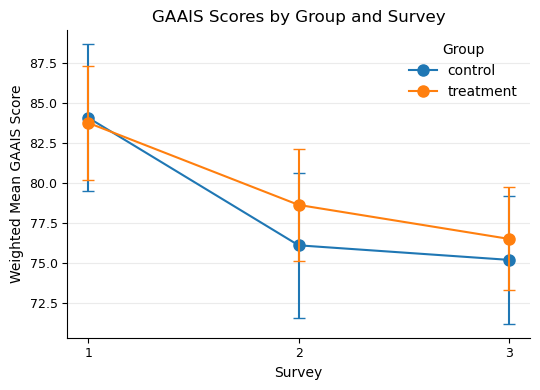

In [29]:
# ── Plot: propensity-weighted GAAIS by Group and Time ───────────────────

fig, ax = plt.subplots(figsize=(5.5, 4))

time_labels = {
    1: "1",
    2: "2",
    3: "3",
}

basic_scores_weighted["time_label"] = (
    basic_scores_weighted["time"].map(time_labels)
)

for group, gdf in basic_scores_weighted.groupby("GROUP"):

    gdf = gdf.sort_values("time")

    line, = ax.plot(
        gdf["time_label"],
        gdf["mean"],
        marker="o",
        linewidth=1.5,
        markersize=8,
        label=group,
    )

    color = line.get_color()

    ax.errorbar(
        gdf["time_label"],
        gdf["mean"],
        yerr=[
            gdf["mean"] - gdf["ci_lo"],
            gdf["ci_hi"] - gdf["mean"],
        ],
        fmt="none",
        capsize=4,
        elinewidth=1.5,
        color=color,
    )

ax.set_xlabel(
    "Survey",
    fontsize=10,
)

ax.set_ylabel(
    "Weighted Mean GAAIS Score",
    fontsize=10,
)

ax.set_title(
    "GAAIS Scores by Group and Survey",
    fontsize=12,
    pad=6,
)

ax.tick_params(
    axis="both",
    labelsize=9,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="y",
    alpha=0.25,
)

ax.legend(
    title="Group",
    frameon=False,
    fontsize=10,
    title_fontsize=10,
)

plt.tight_layout()

plt.savefig(
    "../figures/h2_gaais_by_group_time_weighted.pdf",
    format="pdf",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### H2A: Simple Difference Model

In [30]:
# ── H2A with inverse propensity weighting ──────────────────────────────
h2a_weighted = smf.wls(
    formula="D2 ~ GROUP",
    data=df_wide_weighted,
    weights=df_wide_weighted["stabilized_weight"]
).fit(cov_type="HC1")

print(h2a_weighted.summary())

                            WLS Regression Results                            
Dep. Variable:                     D2   R-squared:                       0.006
Model:                            WLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     1.445
Date:                Sun, 13 Sep 2026   Prob (F-statistic):              0.230
Time:                        11:16:24   Log-Likelihood:                -1128.5
No. Observations:                 301   AIC:                             2261.
Df Residuals:                     299   BIC:                             2268.
Df Model:                           1                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -8.8689      1.133     -7.828      0.0

### H2B: Baseline Adjusted

In [31]:
# ── H2B with inverse propensity weighting ──────────────────────────────
h2b_weighted = smf.wls(
    formula="GAAIS_followup ~ GROUP + GAAIS_baseline",
    data=df_wide_weighted,
    weights=df_wide_weighted["stabilized_weight"]
).fit(cov_type="HC1")

print(h2b_weighted.summary())

                            WLS Regression Results                            
Dep. Variable:         GAAIS_followup   R-squared:                       0.825
Model:                            WLS   Adj. R-squared:                  0.824
Method:                 Least Squares   F-statistic:                     665.2
Date:                Sun, 13 Sep 2026   Prob (F-statistic):          1.29e-110
Time:                        11:16:26   Log-Likelihood:                -1091.7
No. Observations:                 301   AIC:                             2189.
Df Residuals:                     298   BIC:                             2201.
Df Model:                           2                                         
Covariance Type:                  HC1                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          7.5142      1.949      3.

### H3A: Using Spearman-Brown Reliability 

In [32]:
# ── H3A with inverse propensity weighting ──────────────────────────────
h3a_weighted = smf.wls(
    formula="D2 ~ D1 * GROUP + D1 + GROUP",
    data=df_wide_weighted,
    weights=df_wide_weighted["stabilized_weight"]
).fit(cov_type="HC1")

print(h3a_weighted.summary())

                            WLS Regression Results                            
Dep. Variable:                     D2   R-squared:                       0.446
Model:                            WLS   Adj. R-squared:                  0.440
Method:                 Least Squares   F-statistic:                     45.38
Date:                Sun, 13 Sep 2026   Prob (F-statistic):           3.58e-24
Time:                        11:16:29   Log-Likelihood:                -1040.6
No. Observations:                 301   AIC:                             2089.
Df Residuals:                     297   BIC:                             2104.
Df Model:                           3                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -3.5111      0.779     -4.510      0.0

In [33]:
def weighted_corr(x, y, w):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    w = np.asarray(w, dtype=float)

    mean_x = np.average(x, weights=w)
    mean_y = np.average(y, weights=w)

    cov_xy = np.average((x - mean_x) * (y - mean_y), weights=w)
    var_x = np.average((x - mean_x) ** 2, weights=w)
    var_y = np.average((y - mean_y) ** 2, weights=w)

    return cov_xy / np.sqrt(var_x * var_y)

In [34]:
# ── H3A robustness on weighted sample: Split-half attenuation correction ──────────────────────
df_wide_weighted['GAAIS_base_A'] = df_wide_weighted[[f"{c}_t1" for c in items_A]].mean(axis=1)
df_wide_weighted['GAAIS_base_B'] = df_wide_weighted[[f"{c}_t1" for c in items_B]].mean(axis=1)
df_wide_weighted['GAAIS_post_A'] = df_wide_weighted[[f"{c}_t2" for c in items_A]].mean(axis=1)
df_wide_weighted['GAAIS_post_B'] = df_wide_weighted[[f"{c}_t2" for c in items_B]].mean(axis=1)
df_wide_weighted['GAAIS_follow_A'] = df_wide_weighted[[f"{c}_t3" for c in items_A]].mean(axis=1)
df_wide_weighted['GAAIS_follow_B'] = df_wide_weighted[[f"{c}_t3" for c in items_B]].mean(axis=1)

df_wide_weighted['D1_A'] = df_wide_weighted['GAAIS_post_A'] - df_wide_weighted['GAAIS_base_A']
df_wide_weighted['D1_B'] = df_wide_weighted['GAAIS_post_B'] - df_wide_weighted['GAAIS_base_B']

# Spearman-Brown reliability
complete = df_wide_weighted[['D1_A', 'D1_B', 'stabilized_weight']].dropna()
r_halves = weighted_corr(
    complete['D1_A'],
    complete['D1_B'],
    complete['stabilized_weight']
)
reliability  = (2 * r_halves) / (1 + r_halves)

print(f"\nWeighted D1 split-half reliability (Spearman-Brown): r = {reliability:.3f}")

# Attenuation-corrected b3
b3_raw       = h3a_weighted.params.get('D1:GROUP[T.Treatment]', h3a_weighted.params.filter(like='D1:GROUP').iloc[0])
b3_corrected = b3_raw / reliability

print(f"b3 raw:       {b3_raw:.3f}")
print(f"b3 corrected: {b3_corrected:.3f}")


Weighted D1 split-half reliability (Spearman-Brown): r = 0.828
b3 raw:       -0.148
b3 corrected: -0.178


### H3B: Using Random Splits for D1

In [35]:
h3b_weighted = smf.wls(
    formula="D2 ~ D1_A * GROUP + D1_B + GROUP",
    data=df_wide_weighted,
    weights=df_wide_weighted["stabilized_weight"]
).fit(cov_type="HC1")

print(h3b_weighted.summary())

                            WLS Regression Results                            
Dep. Variable:                     D2   R-squared:                       0.457
Model:                            WLS   Adj. R-squared:                  0.449
Method:                 Least Squares   F-statistic:                     35.44
Date:                Sun, 13 Sep 2026   Prob (F-statistic):           3.44e-24
Time:                        11:16:33   Log-Likelihood:                -1037.6
No. Observations:                 301   AIC:                             2085.
Df Residuals:                     296   BIC:                             2104.
Df Model:                           4                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -3.5703      0.809     -4.411      0.0